## Sample the data for inspection

In [57]:
# import pandas as pd

# # Load data from transformed folder (using latest version t03)
# train = pd.read_parquet("../../data/transformed/train_t03.parquet")
# test = pd.read_parquet("../../data/transformed/test_t03.parquet")
# val = pd.read_parquet("../../data/transformed/val_t03.parquet")

# # Create sample data (10% of each split)
# train_sample = train.sample(frac=0.1, random_state=42)
# test_sample = test.sample(frac=0.1, random_state=42)
# val_sample = val.sample(frac=0.1, random_state=42)

# print("=== TRAIN SAMPLE SHAPE ===")
# print(f"Original: {train.shape}, Sample: {train_sample.shape}")

# print("\n=== TEST SAMPLE SHAPE ===")
# print(f"Original: {test.shape}, Sample: {test_sample.shape}")

# print("\n=== VAL SAMPLE SHAPE ===")
# print(f"Original: {val.shape}, Sample: {val_sample.shape}")

# print("\n=== FIRST 5 ROWS (TRAIN SAMPLE) ===")
# print(train_sample.head())

# print("\n=== COLUMN TYPES ===")
# print(train_sample.dtypes)

# print("\n=== TARGET DISTRIBUTION ===")
# target_candidates = ["Results", "Result", "violations_recorded", "Violation", "inspection_result"]
# target_col = next((col for col in target_candidates if col in train_sample.columns), None)
# if target_col is not None:
#     print(f"Using target column: {target_col}")
#     print(train_sample[target_col].value_counts())
# else:
#     print(f"No target column found. Available columns: {list(train_sample.columns)}")

# print("\n=== MISSING VALUES ===")
# print(train_sample.isnull().sum()[train_sample.isnull().sum() > 0])

## Imports

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, confusion_matrix,
    classification_report
)

## Data Loading

In [59]:
TRAIN_PATH = "../../data/transformed/train_t03.parquet"
VAL_PATH   = "../../data/transformed/val_t03.parquet"
TEST_PATH  = "../../data/transformed/test_t03.parquet"

TARGET   = "Results"

train = pd.read_parquet(TRAIN_PATH)
val   = pd.read_parquet(VAL_PATH)
test  = pd.read_parquet(TEST_PATH)

FEATURES = [col for col in train.columns if col != TARGET]

X_train, y_train = train[FEATURES], train[TARGET]
X_val,   y_val   = val[FEATURES],   val[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"\nTarget distribution (train):\n{y_train.value_counts()}")

Train: (109693, 16) | Val: (27483, 16) | Test: (34294, 16)

Target distribution (train):
Results
0    77306
1    32387
Name: count, dtype: int64


## Hyperparamters Search

In [67]:
# Cell — Manual Time-Aware Hyperparameter Search
from sklearn.metrics import recall_score, f1_score
import itertools

# Focused search grid — no CV, uses your actual val split
search_space = {
    "n_estimators":      [200, 300],
    "max_depth":         [10, 15, 20],
    "min_samples_leaf":  [1, 2],
    "class_weight":      [{0:1, 1:3}, {0:1, 1:4}, "balanced"],
}

keys   = list(search_space.keys())
combos = list(itertools.product(*search_space.values()))

print(f"Testing {len(combos)} combinations...\n")

results = []
for combo in combos:
    p = dict(zip(keys, combo))
    p.update({"max_features": "sqrt", "random_state": 42, "n_jobs": -1, "min_samples_split": 5})

    m = RandomForestClassifier(**p)
    m.fit(X_train, y_train)

    y_pred = m.predict(X_val)
    rec = recall_score(y_val, y_pred)
    f1  = f1_score(y_val, y_pred)

    results.append({**p, "val_recall": rec, "val_f1": f1})
    print(f"recall={rec:.4f} | f1={f1:.4f} | {p}")

results_df = pd.DataFrame(results).sort_values("val_recall", ascending=False)

print("\n=== TOP 5 BY RECALL ===")
print(results_df.head(5).to_string(index=False))

Testing 36 combinations...

recall=0.8046 | f1=0.6955 | {'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 1, 'class_weight': {0: 1, 1: 3}, 'max_features': 'sqrt', 'random_state': 42, 'n_jobs': -1, 'min_samples_split': 5}
recall=0.8472 | f1=0.6726 | {'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 1, 'class_weight': {0: 1, 1: 4}, 'max_features': 'sqrt', 'random_state': 42, 'n_jobs': -1, 'min_samples_split': 5}
recall=0.7830 | f1=0.6962 | {'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 1, 'class_weight': 'balanced', 'max_features': 'sqrt', 'random_state': 42, 'n_jobs': -1, 'min_samples_split': 5}
recall=0.8072 | f1=0.6935 | {'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 2, 'class_weight': {0: 1, 1: 3}, 'max_features': 'sqrt', 'random_state': 42, 'n_jobs': -1, 'min_samples_split': 5}
recall=0.8460 | f1=0.6746 | {'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 2, 'class_weight': {0: 1, 1: 4}, 'max_features': 'sqrt', 'random_state': 42, 'n

## Hyperparameters

In [ ]:
params = {
    "n_estimators":      200,
    "max_depth":         10,
    "min_samples_split": 5,
    "min_samples_leaf":  2,
    "max_features":      "sqrt",
    "class_weight":      "balanced",
    "random_state":      42,
    "n_jobs":            -1,
}

## Training

In [80]:
model = RandomForestClassifier(**params)
model.fit(X_train, y_train)

print("Model trained successfully.")
print(f"Number of trees: {model.n_estimators}")

Model trained successfully.
Number of trees: 200


## Validation

In [86]:
y_val_pred = model.predict(X_val)
y_val_prob = model.predict_proba(X_val)[:, 1]

val_cm = confusion_matrix(y_val, y_val_pred)
tn, fp, fn, tp = val_cm.ravel()

val_metrics = {
    # Standard metrics
    "val_accuracy":  accuracy_score(y_val, y_val_pred),
    "val_f1":        f1_score(y_val, y_val_pred),
    "val_roc_auc":   roc_auc_score(y_val, y_val_prob),
    "val_precision": precision_score(y_val, y_val_pred),
    "val_recall":    recall_score(y_val, y_val_pred),
    # Business metrics
    # Restaurants wrongly predicted to pass but actually fail = public health risk
    "val_false_negative_rate":        fn / (fn + tp),
    # Of all failing restaurants, how many did we correctly flag?
    "val_failing_catch_rate":         tp / (tp + fn),
}

print("=== VALIDATION METRICS ===")
for k, v in val_metrics.items():
    print(f"  {k:<35} {v:.4f}")

print(f"\nClassification Report (Val):\n")
print(classification_report(y_val, y_val_pred, target_names=["Pass (0)", "Fail (1)"]))

=== VALIDATION METRICS ===
  val_accuracy                        0.7945
  val_f1                              0.6971
  val_roc_auc                         0.8682
  val_precision                       0.6266
  val_recall                          0.7854
  val_false_negative_rate             0.2146
  val_failing_catch_rate              0.7854

Classification Report (Val):

              precision    recall  f1-score   support

    Pass (0)       0.90      0.80      0.84     19211
    Fail (1)       0.63      0.79      0.70      8272

    accuracy                           0.79     27483
   macro avg       0.76      0.79      0.77     27483
weighted avg       0.82      0.79      0.80     27483



## Testing

In [87]:
y_test_pred = model.predict(X_test)
y_test_prob = model.predict_proba(X_test)[:, 1]

test_cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = test_cm.ravel()

test_metrics = {
    # Standard metrics
    "test_accuracy":  accuracy_score(y_test, y_test_pred),
    "test_f1":        f1_score(y_test, y_test_pred),
    "test_roc_auc":   roc_auc_score(y_test, y_test_prob),
    "test_precision": precision_score(y_test, y_test_pred),
    "test_recall":    recall_score(y_test, y_test_pred),
    # Business metrics
    "test_false_negative_rate":  fn / (fn + tp),
    "test_failing_catch_rate":   tp / (tp + fn),
}

print("=== TEST METRICS ===")
for k, v in test_metrics.items():
    print(f"  {k:<35} {v:.4f}")

print(f"\nClassification Report (Test):\n")
print(classification_report(y_test, y_test_pred, target_names=["Pass (0)", "Fail (1)"]))

=== TEST METRICS ===
  test_accuracy                       0.8592
  test_f1                             0.8555
  test_roc_auc                        0.9266
  test_precision                      0.8543
  test_recall                         0.8567
  test_false_negative_rate            0.1433
  test_failing_catch_rate             0.8567

Classification Report (Test):

              precision    recall  f1-score   support

    Pass (0)       0.86      0.86      0.86     17616
    Fail (1)       0.85      0.86      0.86     16678

    accuracy                           0.86     34294
   macro avg       0.86      0.86      0.86     34294
weighted avg       0.86      0.86      0.86     34294



## Confusion Matrix Plots

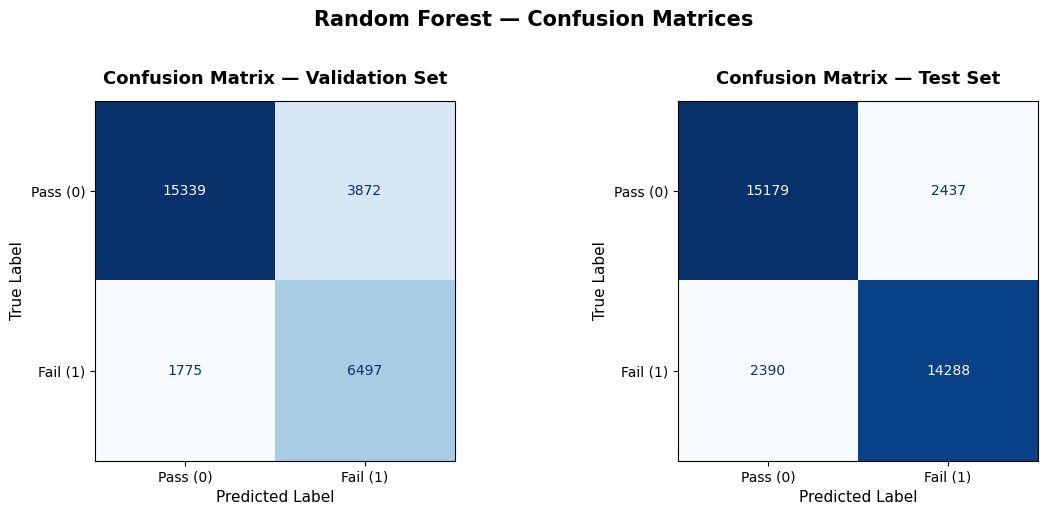

Saved as confusion_matrix_rf.png


In [89]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, cm, title in zip(
    axes,
    [val_cm, test_cm],
    ["Validation Set", "Test Set"]
):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Pass (0)", "Fail (1)"]
    )
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion Matrix — {title}", fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label", fontsize=11)

plt.suptitle("Random Forest — Confusion Matrices", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("confusion_matrix_rf.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved as confusion_matrix_rf.png")

## Feature Importance

In [88]:
importance_df = pd.DataFrame({
    "feature":    FEATURES,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("=== FEATURE IMPORTANCES ===")
print(importance_df.to_string(index=False))

=== FEATURE IMPORTANCES ===
                   feature  importance
           violation_count    0.637434
   inspection_type_encoded    0.124331
days_since_last_inspection    0.057400
    days_to_license_expiry    0.030148
          fail_rate_last_3    0.029338
     facility_type_encoded    0.026765
      has_prior_inspection    0.022188
           inspection_year    0.020245
    prev_inspection_result    0.018136
          inspection_month    0.008296
                      Risk    0.005772
    license_expiry_missing    0.005271
      inspection_dayofweek    0.004936
  application_type_encoded    0.004399
        inspection_quarter    0.003771
                is_revoked    0.001571


## Exporting To MLflow

In [ ]:
# Just verify everything looks correct before handing off.

rf_output = {
    "model":        model,
    "params":       params,
    "val_metrics":  val_metrics,
    "test_metrics": test_metrics,
    "features":     FEATURES,
    "importance":   importance_df,
}

print("Random Forest output ready for experiment_tracking.py")
print(f"Val F1:  {val_metrics['val_f1']:.4f}")
print(f"Test F1: {test_metrics['test_f1']:.4f}")

Random Forest output ready for experiment_tracking.py
Val F1:  0.6971
Test F1: 0.8555
